# The paper's continuous-time network, and where it fails

**Purpose.** Reproduce the first of the paper's two techniques (Raissi, Perdikaris &
Karniadakis, J. Comput. Phys. **378** (2019) 686–707, section 3.1) on van der Pol, and
measure the horizon at which it stops working. That failure is not a nuisance — it is the
paper's own motivation for its second, discrete-time technique, so reproducing it cleanly is
the whole point of this step.

**The technique.** The network *is* the trajectory: time goes in, the state $(y_1, y_2)$
comes out. Physics enters through the loss, not the data:

$$\mathcal{L} \;=\; \underbrace{\big\|y_{\rm net}(0) - y^0\big\|^2}_{\text{starting state}}
\;+\; \underbrace{\frac{1}{N}\sum_{i=1}^{N}\big\|\dot{y}_{\rm net}(t_i) - f\big(y_{\rm net}(t_i)\big)\big\|^2}_{\text{equation residual at collocation times}}$$

where $\dot{y}_{\rm net}$ is obtained by differentiating the network with respect to its own
time input (automatic differentiation), and the $t_i$ are stratified-random collocation times.
**No trajectory data is used in training** — the reference only scores the result.

**The experiment.** Hold everything fixed — architecture (4 hidden layers × 50 units, tanh,
float64), optimiser (full-batch L-BFGS, same iteration budget), collocation density (20 per
time unit) — and grow only the horizon: $T \in \{3, 7, 14, 27, 40\}$, i.e. from under half a
lap of the closed loop to six laps. One network per horizon per seed, three seeds each,
because a single bad initialisation must not masquerade as the method's failure.

Code: `model.py` (network, residual, loss), `training.py` (training, scoring, the sweep).
Data: `results/`. The reference is `RK_Truth/data/trajectories.npz`, start $(2, 0)$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import model as m
import training as tr

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)
RESULTS = tr.RESULTS

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
INK, NET, REF = "#33322e", "#2a78d6", "#e34948"
LAP = tr.LAP
print(f"horizons {tr.HORIZONS} = {[round(T/LAP, 2) for T in tr.HORIZONS]} laps, seeds {tr.SEEDS}")


horizons (3.0, 7.0, 14.0, 27.0, 40.0) = [0.45, 1.05, 2.1, 4.05, 6.0] laps, seeds (0, 1, 2)


## 1. The target

The reference trajectory from $(2, 0)$: half a lap of settling, then steady circulation of
the closed loop. The horizons of the sweep are marked — the shortest covers less than half a
lap, the longest six laps.

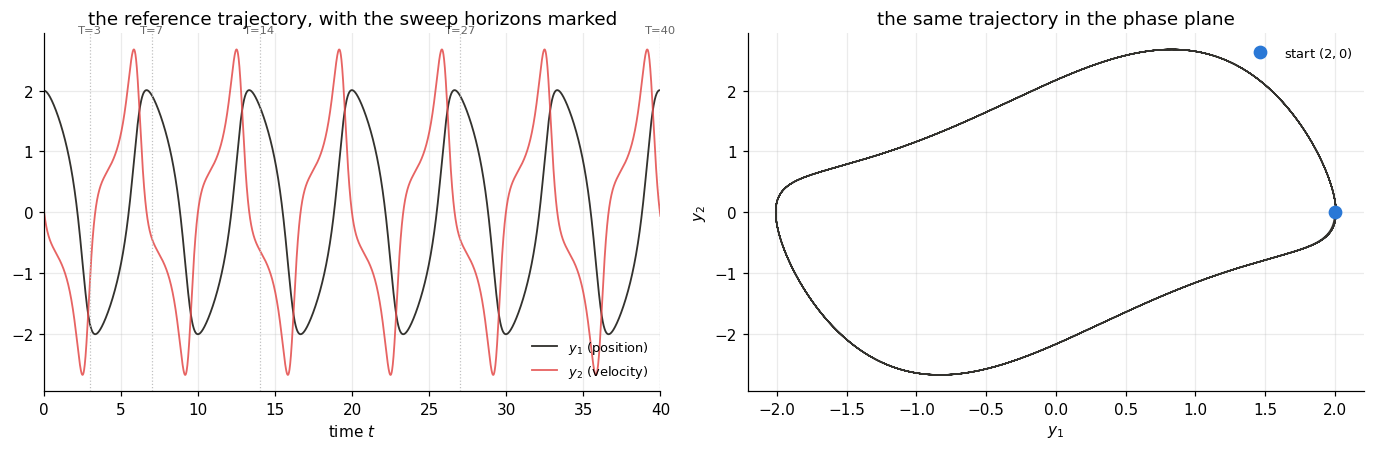

In [2]:
t_ref, y_ref = tr.load_reference()

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.2))
axes[0].plot(t_ref, y_ref[:, 0], color=INK, lw=1.2, label="$y_1$ (position)")
axes[0].plot(t_ref, y_ref[:, 1], color=REF, lw=1.2, alpha=0.85, label="$y_2$ (velocity)")
for T in tr.HORIZONS:
    axes[0].axvline(T, color="0.75", lw=0.8, ls=":")
    axes[0].text(T, 2.95, f"T={T:g}", fontsize=7.5, ha="center", color="0.4")
axes[0].set_xlim(0, 40); axes[0].set_xlabel("time $t$")
axes[0].set_title("the reference trajectory, with the sweep horizons marked")
axes[0].legend(fontsize=8.5, loc="lower right")

axes[1].plot(y_ref[:, 0], y_ref[:, 1], color=INK, lw=0.9)
axes[1].plot(*y_ref[0], "o", color=NET, ms=8, label="start $(2,0)$")
axes[1].set_xlabel("$y_1$"); axes[1].set_ylabel("$y_2$")
axes[1].set_title("the same trajectory in the phase plane")
axes[1].legend(fontsize=8.5)
fig.tight_layout(); fig.savefig(FIGURES / "01_target.png"); plt.show()

## 2. Run the sweep

Fifteen trainings (5 horizons × 3 seeds), each from scratch. The sweep takes about an hour;
it saves everything under `results/`, so it runs only if those files are absent — delete
`results/` to force a full re-run.

In [3]:
summary = tr.run_sweep()          # resumes/loads saved runs; delete results/ to retrain
histories = pd.read_csv(RESULTS / "training_histories.csv")
predictions = np.load(RESULTS / "predictions.npz")
summary

  resuming: 15 of 15 runs already saved


,horizon,laps,seed,n_collocation,restarts_run,seconds,loss_total,loss_start,loss_residual,rel_l2
0,3.0,0.450228,0,60,6,131.8,1.353440e-07,1.198005e-12,1.353428e-07,0.000023
1,3.0,0.450228,1,60,6,134.0,1.818180e-07,4.049885e-12,1.818140e-07,0.000046
2,3.0,0.450228,2,60,6,131.9,1.975471e-07,4.654350e-13,1.975466e-07,0.000038
3,7.0,1.050533,0,140,6,138.7,2.750080e-05,2.465734e-08,2.747615e-05,0.003922
4,7.0,1.050533,1,140,6,140.0,1.293869e-05,4.931414e-09,1.293375e-05,0.000664
5,7.0,1.050533,2,140,6,120.6,2.289225e-06,6.017125e-10,2.288623e-06,0.000477
6,14.0,2.101065,0,280,4,84.6,6.037064e-02,8.793862e-06,6.036184e-02,0.804898
7,14.0,2.101065,1,280,4,90.7,6.052006e-02,7.910441e-06,6.051215e-02,0.793338
8,14.0,2.101065,2,280,4,104.1,6.055561e-02,7.390631e-06,6.054822e-02,0.788897
9,27.0,4.052054,0,540,5,115.7,3.131397e-02,2.583341e-06,3.131139e-02,0.905331


## 3. Did training converge?

The loss after every optimiser restart. This plot exists to separate two very different
failures later on: an optimiser that ran out of budget (loss still falling) versus one that
converged happily to a **wrong answer** (loss flat and small, error large). Only the second
is a verdict on the technique.

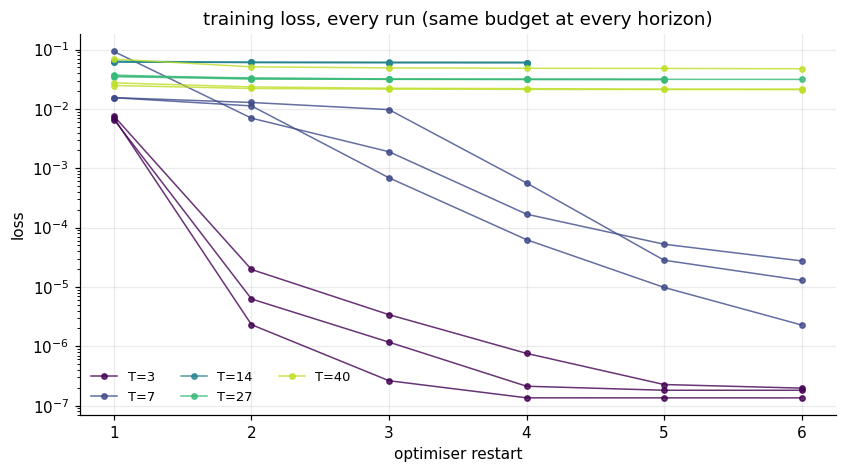

final loss and error per run:


,horizon,laps,seed,loss_total,loss_start,loss_residual,rel_l2
0,3.0,0.450228,0,1.353000e-07,0.000000e+00,1.353000e-07,0.000023
1,3.0,0.450228,1,1.818000e-07,0.000000e+00,1.818000e-07,0.000046
2,3.0,0.450228,2,1.975000e-07,0.000000e+00,1.975000e-07,0.000038
3,7.0,1.050533,0,2.750080e-05,2.470000e-08,2.747610e-05,0.003922
4,7.0,1.050533,1,1.293870e-05,4.900000e-09,1.293380e-05,0.000664
5,7.0,1.050533,2,2.289200e-06,6.000000e-10,2.288600e-06,0.000477
6,14.0,2.101065,0,6.037064e-02,8.793900e-06,6.036184e-02,0.804898
7,14.0,2.101065,1,6.052006e-02,7.910400e-06,6.051215e-02,0.793338
8,14.0,2.101065,2,6.055561e-02,7.390600e-06,6.054822e-02,0.788897
9,27.0,4.052054,0,3.131397e-02,2.583300e-06,3.131139e-02,0.905331


In [4]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
cmap = plt.get_cmap("viridis")
for (T, seed), g in histories.groupby(["horizon", "seed"]):
    color = cmap(0.9 * list(tr.HORIZONS).index(T) / (len(tr.HORIZONS) - 1))
    ax.semilogy(g.outer + 1, g.loss_total, "o-", ms=3.5, lw=1, color=color,
                alpha=0.8, label=f"T={T:g}" if seed == 0 else None)
ax.set_xlabel("optimiser restart"); ax.set_ylabel("loss")
ax.set_title("training loss, every run (same budget at every horizon)")
ax.legend(fontsize=8.5, ncol=3)
fig.tight_layout(); fig.savefig(FIGURES / "02_training_loss.png"); plt.show()

print("final loss and error per run:")
summary[["horizon", "laps", "seed", "loss_total", "loss_start",
         "loss_residual", "rel_l2"]].round(10)

## 4. The headline: relative error against the horizon

Each point is one trained network, scored on the reference over its whole horizon:
$\|y_{\rm net} - y_{\rm ref}\|_2 \,/\, \|y_{\rm ref}\|_2$. The line joins the medians of the
three seeds.

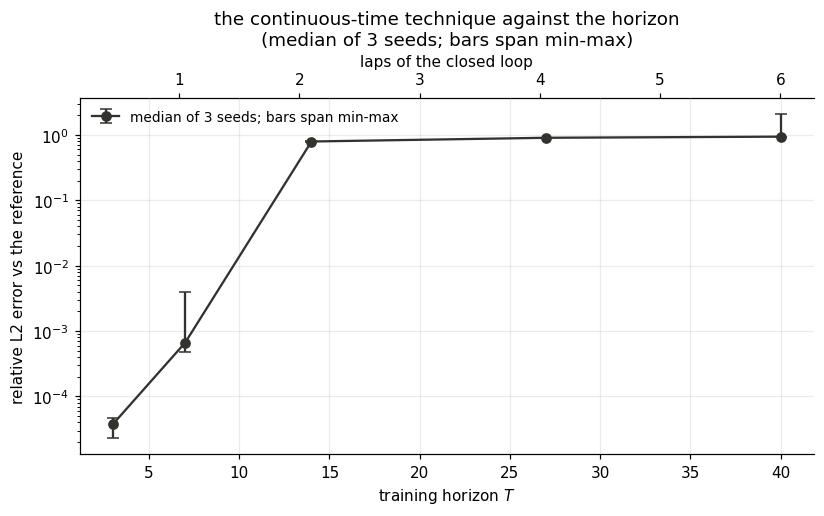

median relative L2 by horizon:
horizon
3.0    3.768e-05
7.0    6.638e-04
14.0   7.933e-01
27.0   9.044e-01
40.0   9.415e-01


In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
g = summary.groupby("horizon").rel_l2
med, lo, hi = g.median(), g.min(), g.max()
ax.errorbar(med.index, med.values,
            yerr=[med.values - lo.values, hi.values - med.values],
            fmt="o-", color=INK, lw=1.5, capsize=4, ms=6,
            label="median of 3 seeds; bars span min-max")
ax.set_yscale("log")
sec = ax.secondary_xaxis("top", functions=(lambda x: x / LAP, lambda x: x * LAP))
sec.set_xlabel("laps of the closed loop")
ax.set_xlabel("training horizon $T$")
ax.set_ylabel("relative L2 error vs the reference")
ax.set_title("the continuous-time technique against the horizon\n"
             "(median of 3 seeds; bars span min-max)")
ax.legend(fontsize=9)
fig.tight_layout(); fig.savefig(FIGURES / "03_error_vs_horizon.png"); plt.show()

print("median relative L2 by horizon:")
print(med.to_string(float_format=lambda v: f"{v:.3e}"))

## 5. What the fits actually look like

The best seed (lowest error) at every horizon, against the reference. This is the figure
that shows *how* the technique fails, not just that it does.

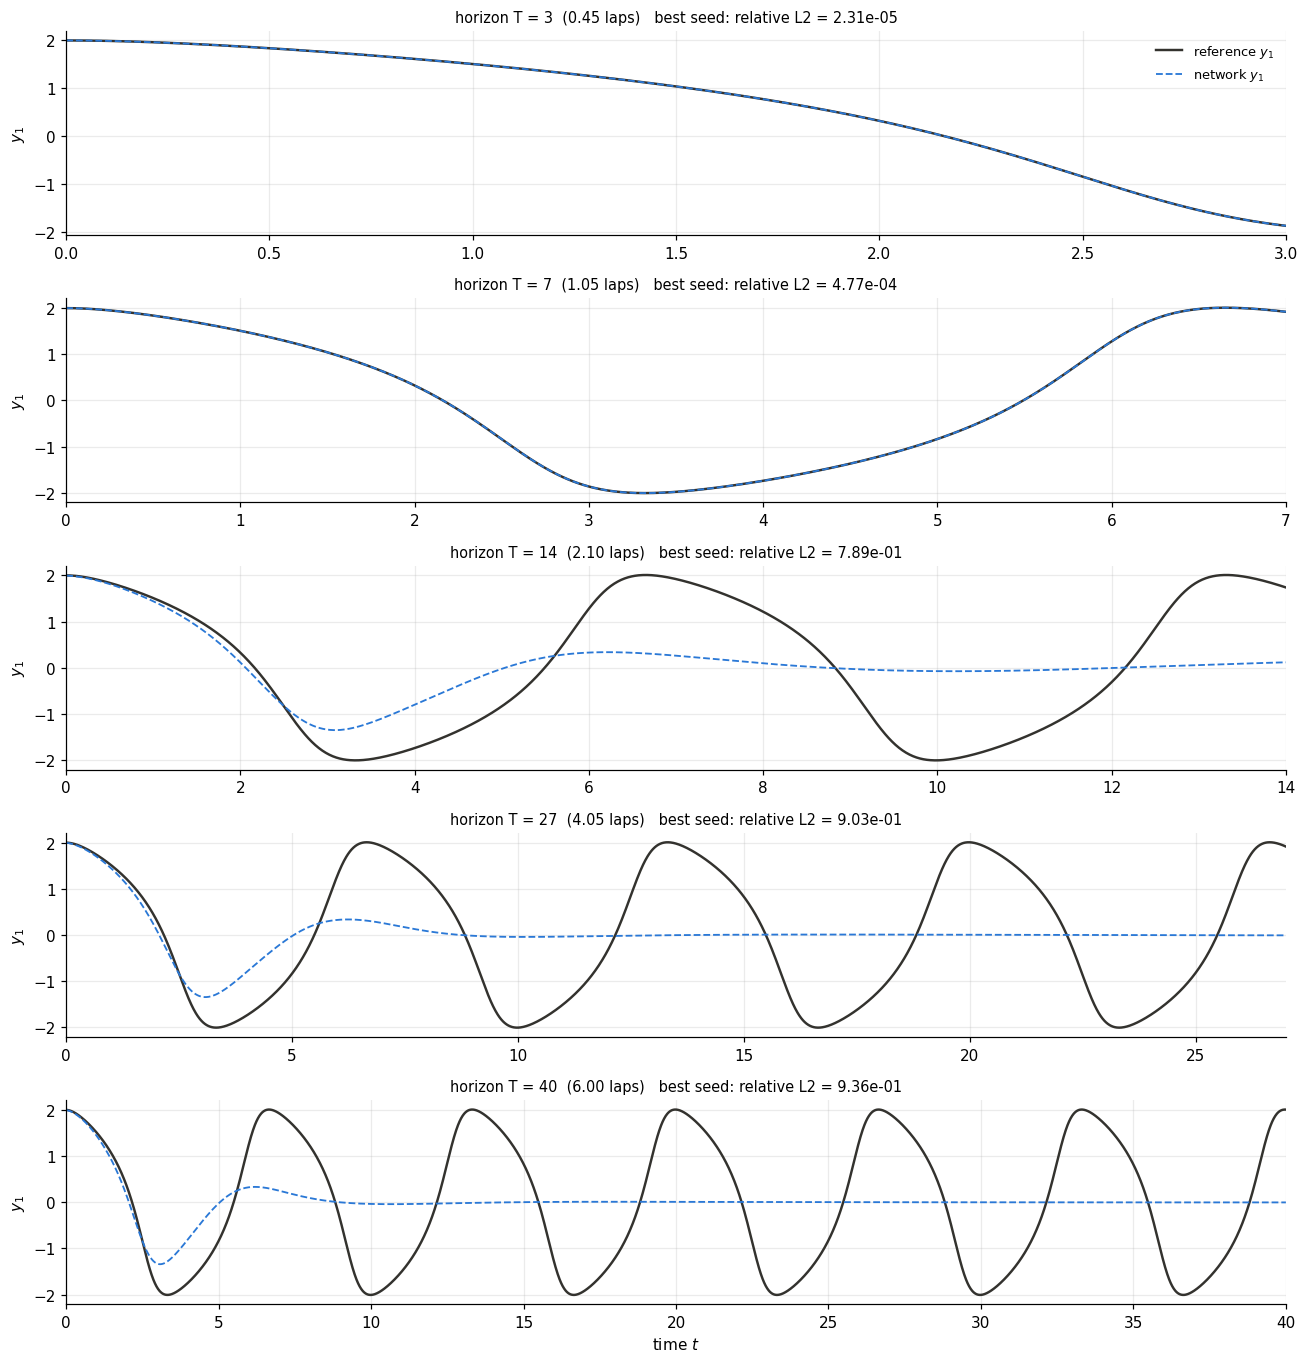

In [6]:
best = summary.loc[summary.groupby("horizon").rel_l2.idxmin()]

fig, axes = plt.subplots(len(tr.HORIZONS), 1, figsize=(12, 2.5 * len(tr.HORIZONS)),
                         sharex=False)
for ax, (_, row) in zip(axes, best.iterrows()):
    T, seed = row.horizon, int(row.seed)
    t = predictions[f"t_T{T:g}"]
    yn = predictions[f"T{T:g}_seed{seed}_y_net"]
    mask = t_ref <= T + 1e-9
    ax.plot(t_ref[mask], y_ref[mask, 0], color=INK, lw=1.6, label="reference $y_1$")
    ax.plot(t, yn[:, 0], color=NET, lw=1.2, ls="--", label="network $y_1$")
    ax.set_xlim(0, T)
    ax.set_ylabel("$y_1$")
    ax.set_title(f"horizon T = {T:g}  ({T/LAP:.2f} laps)   best seed: "
                 f"relative L2 = {row.rel_l2:.2e}", fontsize=9.5)
    if ax is axes[0]:
        ax.legend(fontsize=8.5, loc="upper right")
axes[-1].set_xlabel("time $t$")
fig.tight_layout(); fig.savefig(FIGURES / "04_fits_by_horizon.png"); plt.show()

### The same thing in the phase plane

A correct trajectory circulates on the closed loop. Whatever the failed networks do instead
— collapse toward the (repelling!) equilibrium, lose amplitude, smear the loop — is visible
here at a glance.

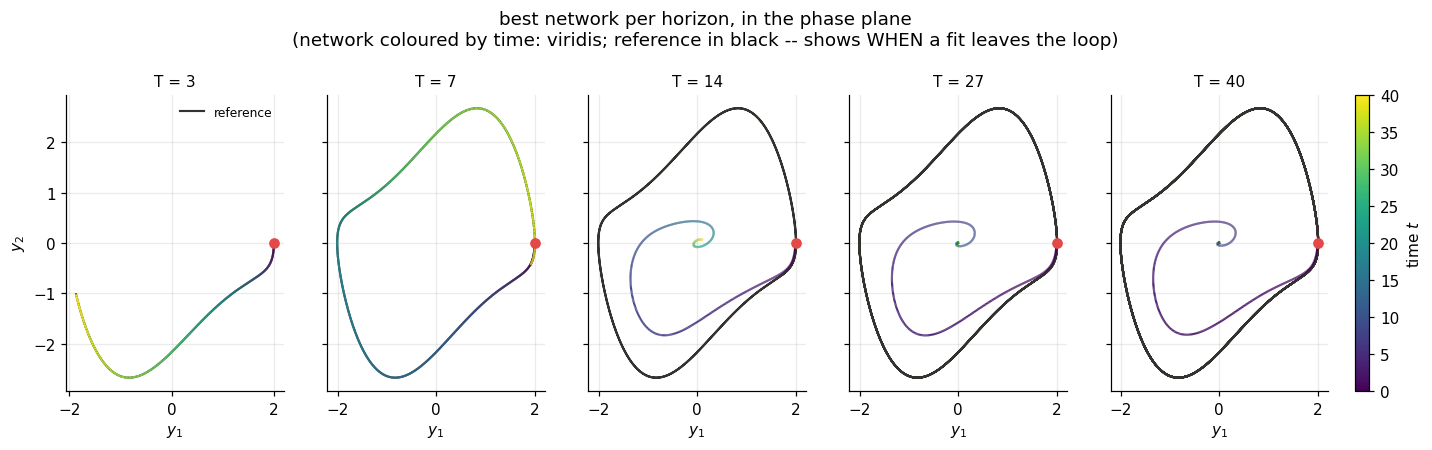

In [7]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def coloured_curve(ax, x, y, t, cmap="viridis"):
    """A line whose colour runs along `t`; returns the mappable for a colorbar."""
    pts = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc = LineCollection(segs, cmap=cmap, norm=Normalize(t.min(), t.max()))
    lc.set_array(t[:-1])
    lc.set_linewidth(1.4)
    ax.add_collection(lc)          # autolim=True by default: updates the axes data limits
    return lc

fig, axes = plt.subplots(1, len(tr.HORIZONS), figsize=(3.1 * len(tr.HORIZONS), 3.5),
                         sharey=True)
lc_last = None
for ax, (_, row) in zip(axes, best.iterrows()):
    T, seed = row.horizon, int(row.seed)
    t = predictions[f"t_T{T:g}"]
    yn = predictions[f"T{T:g}_seed{seed}_y_net"]
    mask = t_ref <= T + 1e-9
    ax.plot(y_ref[mask, 0], y_ref[mask, 1], color=INK, lw=1.4, label="reference")
    lc_last = coloured_curve(ax, yn[:, 0], yn[:, 1], t)
    ax.plot(2, 0, "o", color=REF, ms=6)
    ax.set_title(f"T = {T:g}", fontsize=10)
    ax.set_xlabel("$y_1$")
    ax.relim(); ax.autoscale_view()
axes[0].set_ylabel("$y_2$"); axes[0].legend(fontsize=8)
fig.colorbar(lc_last, ax=axes, label="time $t$", fraction=0.025, pad=0.02)
fig.suptitle("best network per horizon, in the phase plane\n"
             "(network coloured by time: viridis; reference in black -- "
             "shows WHEN a fit leaves the loop)", y=1.1)
fig.savefig(FIGURES / "05_phase_by_horizon.png", bbox_inches="tight"); plt.show()

## 6. Where the error and the residual live in time

Top: the pointwise error, normalised by each component's scale over the horizon (well
defined even where the trajectory crosses zero). Bottom: the magnitude of the **equation
residual** along the network's own trajectory.

The comparison of the two panels is the diagnosis. If the residual is small while the error
is large, the network has found a trajectory that *almost satisfies the equation* but is not
the one passing through the starting state — the equation alone does not pin the answer down,
and a single point of starting-state information at $t=0$ has to propagate across the whole
horizon through the loss landscape. That propagation is exactly what breaks.

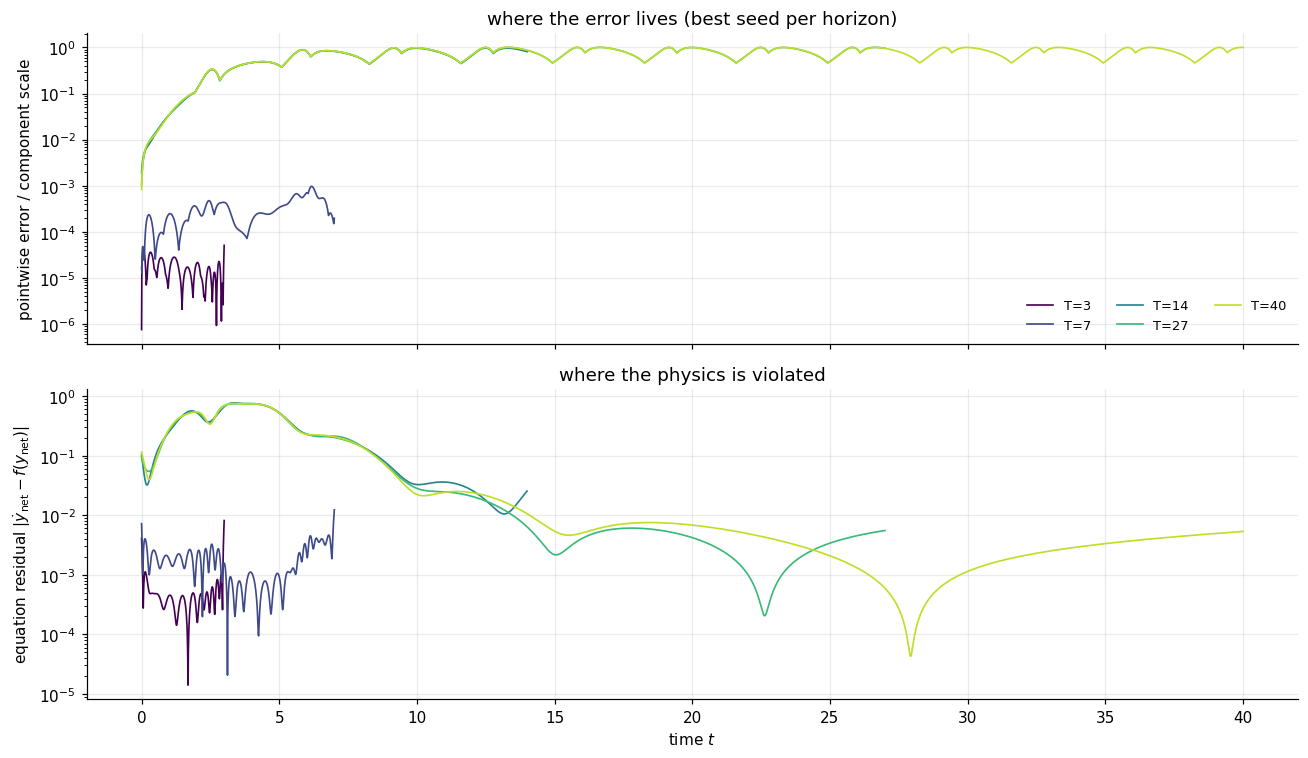

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
cmap = plt.get_cmap("viridis")
for _, row in best.iterrows():
    T, seed = row.horizon, int(row.seed)
    color = cmap(0.9 * list(tr.HORIZONS).index(T) / (len(tr.HORIZONS) - 1))
    t = predictions[f"t_T{T:g}"]
    pw = predictions[f"T{T:g}_seed{seed}_pointwise"]
    res = predictions[f"T{T:g}_seed{seed}_residual"]
    axes[0].semilogy(t, np.maximum(pw.max(axis=1), 1e-12), lw=1.1, color=color,
                     label=f"T={T:g}")
    axes[1].semilogy(t, np.maximum(res, 1e-12), lw=1.1, color=color)
axes[0].set_ylabel("pointwise error / component scale")
axes[0].set_title("where the error lives (best seed per horizon)")
axes[0].legend(fontsize=8.5, ncol=3)
axes[1].set_ylabel("equation residual $|\\dot{y}_{\\rm net} - f(y_{\\rm net})|$")
axes[1].set_xlabel("time $t$")
axes[1].set_title("where the physics is violated")
fig.tight_layout(); fig.savefig(FIGURES / "06_error_and_residual.png"); plt.show()

## 7. Verdict

Summarised numerically below and asserted where the claim is load-bearing. The conclusions
this step feeds forward:

1. **The technique works on short horizons** — sub-percent relative error below about a lap —
   so the machinery (network, residual, optimiser) is sound.
2. **It fails as the horizon grows**, with the architecture, budget and collocation density
   held fixed. This is the paper's own stated motivation for the discrete-time technique, now
   measured on our system.
3. **One network per starting state.** Even where it works, the start $(2,0)$ is baked into
   the weights: nothing about this network transfers to any other starting state. The next
   step removes both limitations at once.

In [9]:
short = summary[summary.horizon <= 7].groupby("horizon").rel_l2.median()
long_ = summary[summary.horizon >= 27].groupby("horizon").rel_l2.median()
print("median relative L2, short horizons :",
      " ".join(f"T={k:g}: {v:.2e}" for k, v in short.items()))
print("median relative L2, long horizons  :",
      " ".join(f"T={k:g}: {v:.2e}" for k, v in long_.items()))

assert short.max() < 1e-2, "expected sub-percent error on short horizons"
assert long_.min() > 10 * short.max(), \
    "expected at least an order of magnitude of degradation at long horizons"
print("\nboth load-bearing claims hold: accurate short, degraded long")

pd.DataFrame(dict(
    horizon=summary.groupby("horizon").rel_l2.median().index,
    laps=[round(T / LAP, 2) for T in summary.groupby("horizon").rel_l2.median().index],
    median_rel_l2=summary.groupby("horizon").rel_l2.median().values,
    worst_seed=summary.groupby("horizon").rel_l2.max().values,
    best_seed=summary.groupby("horizon").rel_l2.min().values,
)).round(6)

median relative L2, short horizons : T=3: 3.77e-05 T=7: 6.64e-04
median relative L2, long horizons  : T=27: 9.04e-01 T=40: 9.42e-01

both load-bearing claims hold: accurate short, degraded long


,horizon,laps,median_rel_l2,worst_seed,best_seed
0,3.0,0.45,0.000038,0.000046,0.000023
1,7.0,1.05,0.000664,0.003922,0.000477
2,14.0,2.10,0.793338,0.804898,0.788897
3,27.0,4.05,0.904441,0.905331,0.903169
4,40.0,6.00,0.941514,2.092121,0.936497
